# v4 analysis: the "self" diagnostic (continual vs Hindi-only, both from scratch)
For every saved checkpoint: record MLP neuron activations on fixed inputs, correlate every pair of neurons,
link pairs with |r| >= tau, and call the largest connected group the **self** (the rest = **task**).
At every transition between consecutive checkpoints: match neurons (Hungarian), measure each neuron's change,
and compare self vs task vs a random group of the same size. Also tracked: whether the self keeps the **same members**.

* Phase 0 is the random model, so the transition 0 → 1 is skipped (it is not a language switch).
* Both runs are cut to the same last phase (`MATCH_PHASES`), so the comparison is fair while the continual run is still training.
* Runs on GPU 1 and only reads checkpoints, so it can run while training continues on GPU 0.

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "1"          # run this cell FIRST in a fresh kernel
REPO = "/workspace/shreshth"
os.chdir(REPO); sys.path.insert(0, REPO)
from common_v4 import *
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")

device: cuda | NVIDIA GeForce RTX 3090


In [2]:
!nvidia-smi

Wed Oct  7 19:01:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:08:00.0 Off |                  N/A |
| 66%   74C    P2            321W /  325W |   23367MiB /  24576MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from IPython.display import display
torch.backends.cuda.matmul.allow_tf32 = False      # full precision for correlations

RUNS = {"continual": "v4_continual_s0", "only_hi": "v4_only_hi_s0"}
TAUS = [0.15, 0.2, 0.25, 0.3, 0.4, 0.5]  # all computed in one pass
TAU_PLOT = 0.3                         # used for plots; pick it from the tau sweep (section 4)
MAX_T = 24000                          # token positions per trace (fixed random subset)
N_RANDOM = 20                          # random size-matched groups per transition
MATCH_PHASES = True                    # cut every run to the last phase all runs have reached
MAX_PHASE = None                       # or set e.g. 6 to analyse phases 0-6 only (quick test)
OUT = P("analysis", "v4"); os.makedirs(OUT, exist_ok=True)

def ckpts_of(run):
    return sorted(glob.glob(P("runs", run, "ckpt", "p*.pt")))
def phase_of(path):
    return int(os.path.basename(path)[1:4])

avail = {k: ckpts_of(v) for k, v in RUNS.items()}
for k, v in avail.items():
    print(f"{k:10s}: {len(v)} checkpoints, last phase {phase_of(v[-1]) if v else None}")
last = min(phase_of(v[-1]) for v in avail.values() if v) if MATCH_PHASES else None
if MAX_PHASE is not None:
    last = MAX_PHASE if last is None else min(last, MAX_PHASE)
print("analysing phases 0 ..", last if last is not None else "all")

continual : 11 checkpoints, last phase 10
only_hi   : 19 checkpoints, last phase 18
analysing phases 0 .. 10


## 1. Sanity check: phase 1 should be (nearly) the same model in both runs

In [4]:
p1 = {k: [p for p in v if phase_of(p) == 1] for k, v in avail.items()}
if all(p1.values()):
    a = torch.load(p1["continual"][0], map_location="cpu")["model"]
    b = torch.load(p1["only_hi"][0], map_location="cpu")["model"]
    rel = {k: ((a[k].float() - b[k].float()).norm() / (a[k].float().norm() + 1e-12)).item() for k in a}
    print(f"phase-1 weights, relative difference: median {np.median(list(rel.values())):.2e}, max {max(rel.values()):.2e}")
    print("(small but non-zero is expected: GPU arithmetic is not perfectly deterministic)")

phase-1 weights, relative difference: median 7.42e-02, max 9.82e-01
(small but non-zero is expected: GPU arithmetic is not perfectly deterministic)


## 2. Recording activations on fixed inputs

In [5]:
DEV_EN = read_flores("dev", "en")
SRC_IDS = [sp.encode(s)[:MAX_TOK - 1] + [EOS] for s in DEV_EN]
TGT_IN = {l: [[LANG_TAG[l]] + sp.encode(r)[:MAX_TOK - 1] for r in read_flores("dev", l)] for l in LANGS}

@torch.no_grad()
def record(model, bs=64):
    """MLP (GELU-output) activations at every real token.
    enc{j}: English tokens (same input for every checkpoint).
    dec{j}: target tokens of hi/zh/ar, teacher-forced; dec_lang = language of each position."""
    model.eval()
    cur = {}
    hooks = [b.mlp.act.register_forward_hook(lambda m, i, o, k=f"enc{j}": cur.__setitem__(k, o))
             for j, b in enumerate(model.enc_blocks)]
    hooks += [b.mlp.act.register_forward_hook(lambda m, i, o, k=f"dec{j}": cur.__setitem__(k, o))
              for j, b in enumerate(model.dec_blocks)]
    names = [f"enc{j}" for j in range(len(model.enc_blocks))] + [f"dec{j}" for j in range(len(model.dec_blocks))]
    acts, dec_lang = {k: [] for k in names}, []
    for s in range(0, len(SRC_IDS), bs):
        src = pad_batch(SRC_IDS[s:s + bs])
        mem, src_mask = model.encode(src)
        keep = (src != PAD) & (src != EOS)
        for k in names:
            if k.startswith("enc"):
                acts[k].append(cur[k][keep].half())
        for li, l in enumerate(LANGS):
            tgt = pad_batch(TGT_IN[l][s:s + bs])
            model.decode(tgt, mem, src_mask)
            keep = tgt != PAD
            keep[:, 0] = False                              # skip the language-tag position
            for k in names:
                if k.startswith("dec"):
                    acts[k].append(cur[k][keep].half())
            dec_lang.append(torch.full((int(keep.sum()),), li, device=DEVICE))
    for h in hooks:
        h.remove()
    return {k: torch.cat(v) for k, v in acts.items()}, torch.cat(dec_lang)

def subsample_idx(n, k, seed=0):
    if n <= k:
        return torch.arange(n, device=DEVICE)
    return torch.tensor(np.sort(np.random.default_rng(seed).choice(n, k, replace=False)), device=DEVICE)

def dec_subsample(dec_lang, k, seed=1):
    """Equal number of decoder positions from each language."""
    g, lang_np, out = np.random.default_rng(seed), dec_lang.cpu().numpy(), []
    for li in range(len(LANGS)):
        pos = np.nonzero(lang_np == li)[0]
        out.append(np.sort(g.choice(pos, min(len(pos), k // len(LANGS)), replace=False)))
    return torch.tensor(np.concatenate(out), device=DEVICE)

## 3. The diagnostic: traces → correlations → blocks → matching → change

In [6]:
def traces(X, groups=None):
    """X: (T, d). Remove each language's mean per neuron (decoder), then z-score each neuron."""
    X = X.clone()
    if groups is not None:
        for g in groups.unique():
            m = groups == g
            X[m] -= X[m].mean(0, keepdim=True)
    mu, sd = X.mean(0, keepdim=True), X.std(0, unbiased=False, keepdim=True)
    alive = sd[0] > 1e-6
    Z = (X - mu) / torch.where(sd > 0, sd, torch.ones_like(sd))
    Z[:, ~alive] = 0
    return Z, alive

def largest_block(R, alive, tau):
    """Link alive neurons with |r| >= tau; largest connected group = self."""
    if int(alive.sum()) == 0:
        return torch.zeros_like(alive), 0
    A = (R.abs() >= tau) & alive[:, None] & alive[None, :]
    A.fill_diagonal_(False)
    _, lab = connected_components(csr_matrix(A.cpu().numpy()), directed=False)
    lab = np.where(alive.cpu().numpy(), lab, -1)
    sizes = np.bincount(lab[lab >= 0])
    return torch.tensor(lab == sizes.argmax(), device=DEVICE), int(sizes.max())

def transition(Za, Ra, alive_a, Zb, Rb, alive_b):
    """Hungarian matching a -> b, then per-neuron % change = 100 x (1 - mean(activation sim, connectivity sim))."""
    S = (Za.T @ Zb) / Za.shape[0]
    _, perm = linear_sum_assignment(-S.double().cpu().numpy())
    perm = torch.tensor(perm, device=DEVICE)
    act = S[torch.arange(len(perm), device=DEVICE), perm]
    A_ = Ra.clone(); A_.fill_diagonal_(0)
    B_ = Rb[perm][:, perm].clone(); B_.fill_diagonal_(0)
    conn = (A_ * B_).sum(1) / (A_.norm(dim=1) * B_.norm(dim=1) + 1e-12)
    change = 100 * (1 - (act + conn) / 2)
    valid = alive_a & alive_b[perm]
    return perm, change, valid

def analyze_run(name, run):
    paths = [p for p in avail[name] if last is None or phase_of(p) <= last]
    print(f"\n=== {name} ({run}): {len(paths)} checkpoints ===")
    block_rows, trans_rows, idx, prev, keep_R = [], [], {}, None, {}
    for path in paths:
        t0 = time.time()
        model, ck = load_model(path)
        phase, lang = ck["phase"], ck["lang"]
        acts, dec_lang = record(model)
        if not idx:
            idx["enc"] = subsample_idx(acts["enc0"].shape[0], MAX_T)
            idx["dec"] = dec_subsample(dec_lang, MAX_T)
        layers = {}
        for lname, X in acts.items():
            kind = lname[:3]
            Z, alive = traces(X[idx[kind]].float(), dec_lang[idx["dec"]] if kind == "dec" else None)
            R = Z.T @ Z / Z.shape[0]
            selfm = {}
            for tau in TAUS:
                m, size = largest_block(R, alive, tau)
                selfm[tau] = m
                block_rows.append({"run": name, "phase": phase, "lang": lang, "layer": lname, "tau": tau,
                                   "self_size": size, "n_alive": int(alive.sum()),
                                   "self_frac": size / max(int(alive.sum()), 1)})
            layers[lname] = (Z, R, alive, selfm)
            keep_R[(phase, lname)] = (R.cpu().numpy().astype(np.float16), alive.cpu().numpy())
        del acts
        if prev is not None and prev["phase"] >= 1:          # skip random model -> phase 1
            gen = torch.Generator(device=DEVICE).manual_seed(int(phase))
            for lname, (Zb, Rb, alive_b, selfm_b) in layers.items():
                Za, Ra, alive_a, selfm_a = prev["layers"][lname]
                perm, change, valid = transition(Za, Ra, alive_a, Zb, Rb, alive_b)
                vidx = valid.nonzero().squeeze(1)
                for tau in TAUS:
                    in_self = valid & selfm_b[tau][perm]       # target-side membership, as in the paper
                    in_task = valid & ~selfm_b[tau][perm]
                    ns = int(in_self.sum())
                    sc = change[in_self].mean().item() if ns else float("nan")
                    tc = change[in_task].mean().item() if in_task.any() else float("nan")
                    rc = float("nan")
                    if 0 < ns < len(vidx):
                        rc = float(np.mean([change[vidx[torch.randperm(len(vidx), generator=gen,
                                            device=DEVICE)[:ns]]].mean().item() for _ in range(N_RANDOM)]))
                    sa, sb = selfm_a[tau], selfm_b[tau][perm]  # self before, and partners' self membership after
                    union = int((sa | sb).sum())
                    overlap = int((sa & sb).sum()) / union if union else float("nan")
                    trans_rows.append({"run": name, "from_phase": prev["phase"], "to_phase": phase,
                                       "from_lang": prev["lang"], "to_lang": lang, "layer": lname, "tau": tau,
                                       "n_self": ns, "self_change": sc, "task_change": tc, "random_change": rc,
                                       "gap": tc - sc, "gap_vs_random": rc - sc, "self_overlap": overlap})
        prev = {"phase": phase, "lang": lang, "layers": layers}
        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        print(f"  phase {phase:2d} ({lang}) done in {time.time() - t0:.0f}s")
    B, T = pd.DataFrame(block_rows), pd.DataFrame(trans_rows)
    B.to_csv(f"{OUT}/{name}_blocks.csv", index=False)
    T.to_csv(f"{OUT}/{name}_transitions.csv", index=False)
    return {"blocks": B, "trans": T, "R": keep_R, "last_phase": prev["phase"] if prev else None}

In [7]:
results = {name: analyze_run(name, run) for name, run in RUNS.items() if avail[name]}
LAYERS = sorted({l for r in results.values() for (_, l) in r["R"]}, key=lambda s: (s[:3] != "enc", s))
print("layers:", LAYERS)


=== continual (v4_continual_s0): 11 checkpoints ===
  phase  0 (init) done in 5s
  phase  1 (hi) done in 4s
  phase  2 (zh) done in 12s
  phase  3 (ar) done in 12s
  phase  4 (hi) done in 12s
  phase  5 (zh) done in 9s
  phase  6 (ar) done in 9s
  phase  7 (hi) done in 9s
  phase  8 (zh) done in 6s
  phase  9 (ar) done in 7s
  phase 10 (hi) done in 7s

=== only_hi (v4_only_hi_s0): 11 checkpoints ===
  phase  0 (init) done in 4s
  phase  1 (hi) done in 4s
  phase  2 (hi) done in 5s
  phase  3 (hi) done in 5s
  phase  4 (hi) done in 5s
  phase  5 (hi) done in 5s
  phase  6 (hi) done in 5s
  phase  7 (hi) done in 5s
  phase  8 (hi) done in 5s
  phase  9 (hi) done in 5s
  phase 10 (hi) done in 5s
layers: ['enc0', 'enc1', 'enc2', 'enc3', 'dec0', 'dec1', 'dec2', 'dec3']


## 4. Tau sweep: size of the self (fraction of alive neurons)
Pick `TAU_PLOT` where the self is a real part of the layer, but not the whole layer.

In [8]:
for name, r in results.items():
    B = r["blocks"]
    for ph, label in [(1, "after phase 1 (Hindi only, no switch yet)"), (r["last_phase"], "latest phase")]:
        tab = B[B.phase == ph].pivot(index="tau", columns="layer", values="self_frac")[LAYERS]
        print(f"{name}, phase {ph}: {label}")
        display(tab.round(2))

continual, phase 1: after phase 1 (Hindi only, no switch yet)


layer,enc0,enc1,enc2,enc3,dec0,dec1,dec2,dec3
tau,,,,,,,,
0.15,0.97,0.93,0.89,0.95,0.98,0.95,0.94,0.96
0.20,0.70,0.62,0.60,0.70,0.82,0.70,0.66,0.74
0.25,0.36,0.36,0.38,0.45,0.59,0.45,0.41,0.50
0.30,0.18,0.21,0.22,0.26,0.44,0.28,0.25,0.34
0.40,0.02,0.04,0.05,0.05,0.27,0.13,0.09,0.15
0.50,0.01,0.02,0.02,0.02,0.16,0.02,0.04,0.05


continual, phase 10: latest phase


layer,enc0,enc1,enc2,enc3,dec0,dec1,dec2,dec3
tau,,,,,,,,
0.15,0.90,0.80,0.80,0.89,0.89,0.77,0.79,0.91
0.20,0.49,0.46,0.50,0.62,0.56,0.43,0.48,0.68
0.25,0.25,0.23,0.23,0.33,0.22,0.16,0.25,0.46
0.30,0.12,0.11,0.06,0.08,0.08,0.02,0.12,0.30
0.40,0.02,0.01,0.01,0.01,0.02,0.01,0.01,0.11
0.50,0.00,0.00,0.01,0.01,0.01,0.01,0.01,0.04


only_hi, phase 1: after phase 1 (Hindi only, no switch yet)


layer,enc0,enc1,enc2,enc3,dec0,dec1,dec2,dec3
tau,,,,,,,,
0.15,0.97,0.92,0.89,0.94,0.98,0.95,0.94,0.96
0.20,0.68,0.61,0.59,0.69,0.83,0.71,0.66,0.75
0.25,0.35,0.34,0.37,0.44,0.59,0.47,0.42,0.51
0.30,0.11,0.20,0.22,0.24,0.44,0.29,0.27,0.36
0.40,0.02,0.04,0.05,0.04,0.26,0.13,0.11,0.17
0.50,0.01,0.02,0.02,0.02,0.16,0.03,0.03,0.07


only_hi, phase 10: latest phase


layer,enc0,enc1,enc2,enc3,dec0,dec1,dec2,dec3
tau,,,,,,,,
0.15,0.92,0.83,0.77,0.83,0.98,0.90,0.88,0.92
0.20,0.56,0.47,0.46,0.53,0.83,0.65,0.56,0.64
0.25,0.27,0.26,0.26,0.28,0.63,0.42,0.34,0.42
0.30,0.06,0.15,0.12,0.13,0.46,0.24,0.21,0.26
0.40,0.02,0.02,0.02,0.02,0.30,0.10,0.04,0.08
0.50,0.01,0.01,0.01,0.01,0.19,0.04,0.01,0.03


## 5. Training curves (script-restricted chrF and val loss after each phase)

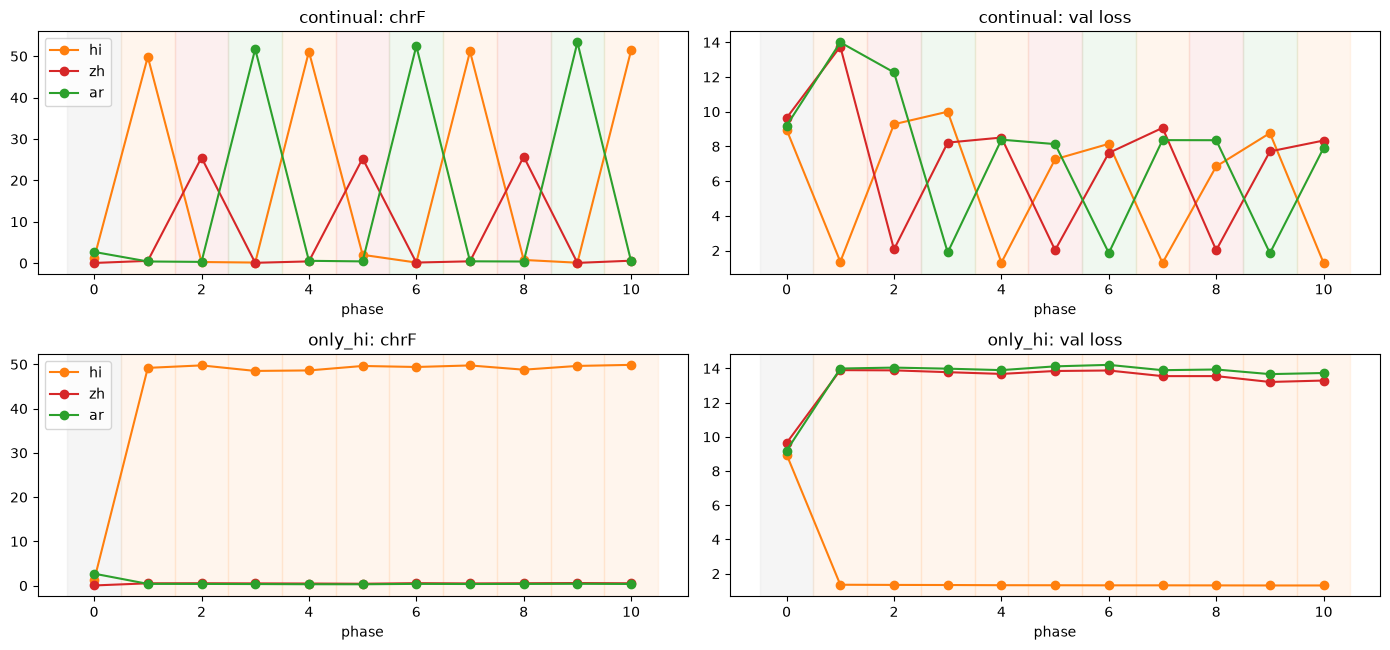

continual


,phase,trained,steps,stop,chrF hi,chrF zh,chrF ar,val hi,val zh,val ar
0,0,init,0,init,1.18,0.04,2.71,8.9647,9.6408,9.1963
1,1,hi,32000,plateau,49.86,0.55,0.40,1.3577,13.7522,13.9963
2,2,zh,14500,plateau,0.27,25.50,0.30,9.2801,2.0683,12.2672
3,3,ar,16500,plateau,0.14,0.08,51.74,10.0015,8.2214,1.8923
4,4,hi,22500,plateau,51.13,0.42,0.56,1.3103,8.5118,8.3896
5,5,zh,11000,plateau,2.01,25.28,0.42,7.2610,2.0276,8.1345
6,6,ar,13000,plateau,0.14,0.14,52.46,8.1500,7.6268,1.8606
7,7,hi,18500,plateau,51.15,0.44,0.44,1.2895,9.0694,8.3636
8,8,zh,9500,plateau,0.77,25.73,0.39,6.8502,2.0239,8.3584
9,9,ar,11500,plateau,0.10,0.06,53.34,8.7691,7.7124,1.8521


only_hi


,phase,trained,steps,stop,chrF hi,chrF zh,chrF ar,val hi,val zh,val ar
0,0,init,0,init,1.18,0.04,2.71,8.9647,9.6408,9.1963
1,1,hi,34500,plateau,49.20,0.53,0.40,1.3516,13.8983,13.9921
2,2,hi,6000,plateau,49.76,0.54,0.39,1.3417,13.8854,14.0464
3,3,hi,6000,plateau,48.51,0.51,0.36,1.3354,13.7794,13.9841
4,4,hi,6000,plateau,48.62,0.48,0.32,1.3246,13.6776,13.8992
5,5,hi,6000,plateau,49.63,0.43,0.31,1.3216,13.8483,14.1192
6,6,hi,6000,plateau,49.40,0.56,0.40,1.3169,13.8771,14.2065
7,7,hi,6000,plateau,49.75,0.50,0.37,1.3171,13.5483,13.8953
8,8,hi,6000,plateau,48.79,0.54,0.39,1.3135,13.5490,13.9358
9,9,hi,6000,plateau,49.64,0.59,0.42,1.3094,13.2070,13.6655


In [9]:
def read_phases(run):
    rows = {}
    for l in open(P("runs", run, "phases.jsonl")):
        r = json.loads(l); rows[r["phase"]] = r
    return [rows[k] for k in sorted(rows) if last is None or k <= last]

COL = {"hi": "C1", "zh": "C3", "ar": "C2", "init": "C7"}
fig, axes = plt.subplots(len(results), 2, figsize=(14, 3.3 * len(results)), squeeze=False)
for row, name in enumerate(results):
    ph = read_phases(RUNS[name])
    x = [r["phase"] for r in ph]
    for l in LANGS:
        axes[row, 0].plot(x, [r["chrf_masked"][l] for r in ph], marker="o", color=COL[l], label=l)
        axes[row, 1].plot(x, [r["val_masked"][l] for r in ph], marker="o", color=COL[l], label=l)
    axes[row, 0].set_title(f"{name}: chrF"); axes[row, 1].set_title(f"{name}: val loss")
    for ax in axes[row]:
        ax.set_xlabel("phase")
        for r in ph:
            ax.axvspan(r["phase"] - 0.5, r["phase"] + 0.5, alpha=0.07, color=COL.get(r["lang"], "C7"))
    axes[row, 0].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/fig_training_curves.png", dpi=120); plt.show()

for name in results:
    tab = pd.DataFrame([{"phase": r["phase"], "trained": r["lang"], "steps": r["steps"], "stop": r["reason"],
                         **{f"chrF {l}": r["chrf_masked"][l] for l in LANGS},
                         **{f"val {l}": r["val_masked"][l] for l in LANGS}} for r in read_phases(RUNS[name])])
    print(name); display(tab)
    tab.to_csv(f"{OUT}/{name}_phases.csv", index=False)

## 6. The self block, highlighted (latest phase, self neurons first, gold box)

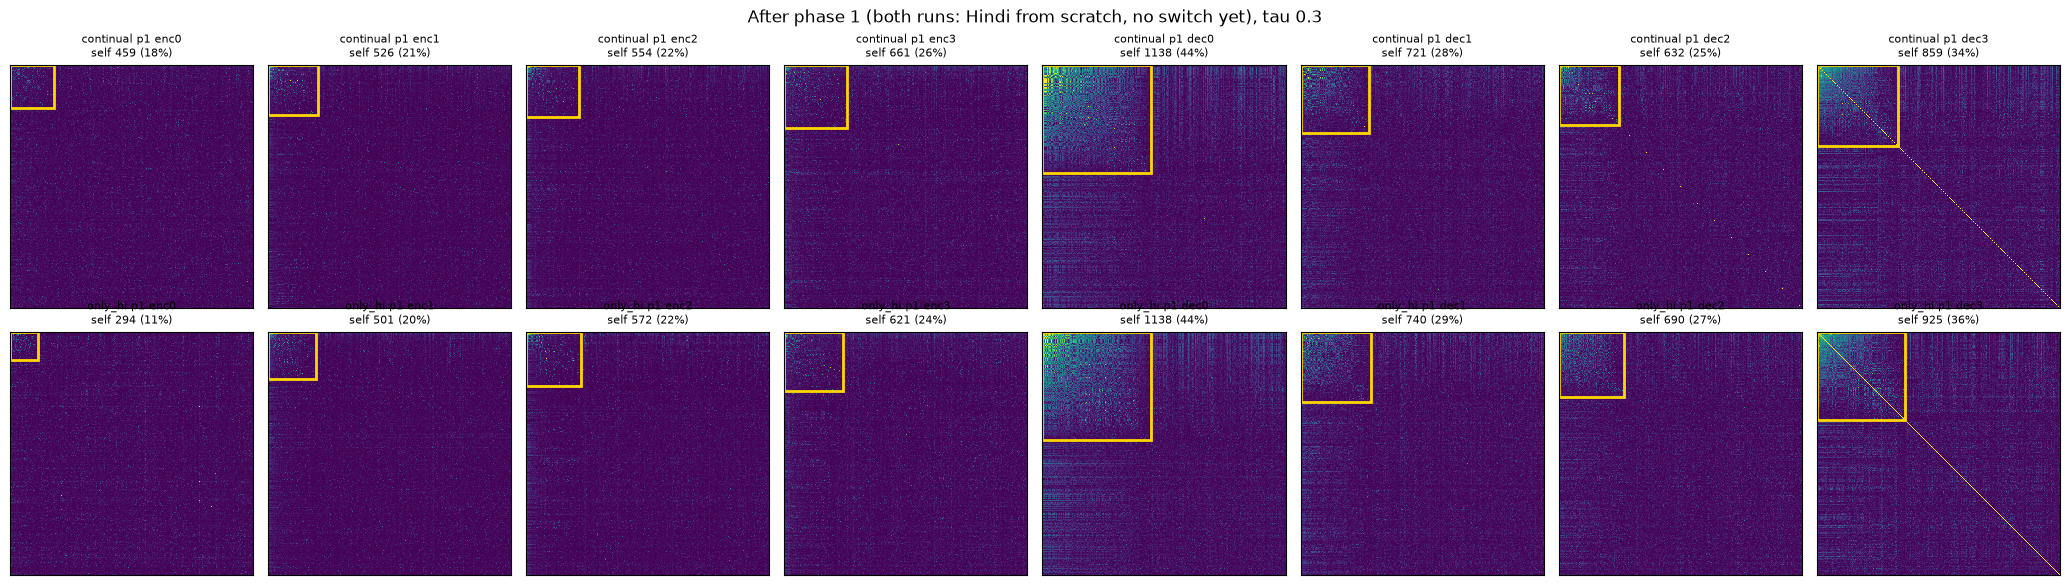

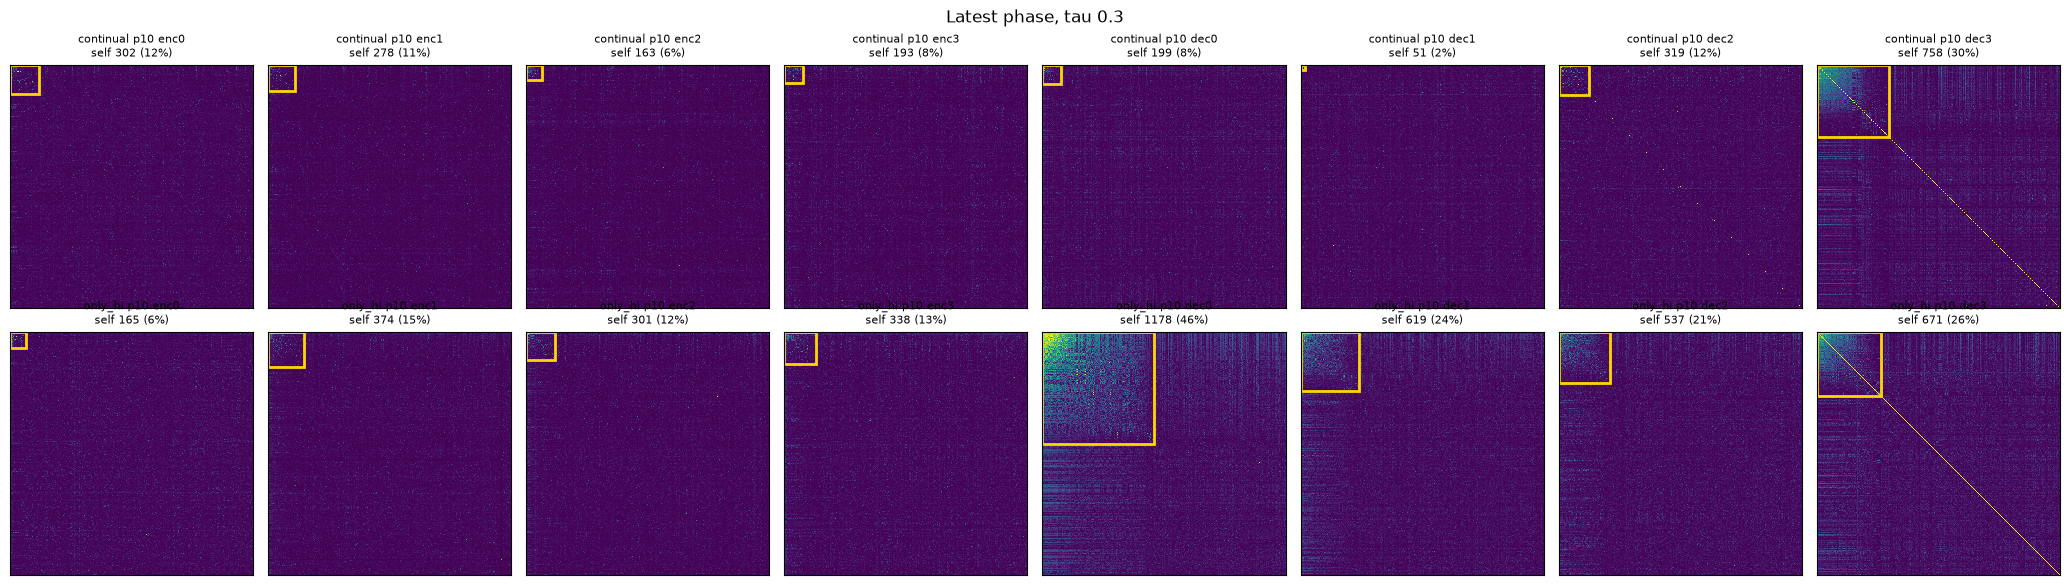

In [10]:
def self_mask_np(R, alive, tau):
    A = (np.abs(R) >= tau) & alive[:, None] & alive[None, :]
    np.fill_diagonal(A, False)
    _, lab = connected_components(csr_matrix(A), directed=False)
    lab = np.where(alive, lab, -1)
    return lab == np.bincount(lab[lab >= 0]).argmax()

def plot_self_blocks(phase_for, title):
    fig, axes = plt.subplots(len(results), len(LAYERS), figsize=(2.6 * len(LAYERS), 3.0 * len(results)), squeeze=False)
    for row, (name, r) in enumerate(results.items()):
        ph = phase_for(r)
        for col, l in enumerate(LAYERS):
            R, alive = r["R"][(ph, l)]
            R = R.astype(np.float32)
            m = self_mask_np(R, alive, TAU_PLOT)
            s_idx = np.where(m)[0]
            s_idx = s_idx[np.argsort(-np.abs(R[np.ix_(s_idx, s_idx)]).mean(1))]
            order = np.concatenate([s_idx, np.where(alive & ~m)[0]])
            ax = axes[row, col]
            ax.imshow(np.abs(R[np.ix_(order, order)]), vmin=0, vmax=0.6, cmap="viridis", interpolation="nearest")
            ax.add_patch(patches.Rectangle((-0.5, -0.5), len(s_idx), len(s_idx), fill=False, edgecolor="gold", lw=2))
            ax.set_title(f"{name} p{ph} {l}\nself {len(s_idx)} ({100 * len(s_idx) / max(alive.sum(), 1):.0f}%)", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{title}, tau {TAU_PLOT}")
    plt.tight_layout()
    return fig

plot_self_blocks(lambda r: 1, "After phase 1 (both runs: Hindi from scratch, no switch yet)")
plt.savefig(f"{OUT}/fig_self_block_phase1_tau{TAU_PLOT}.png", dpi=120); plt.show()
plot_self_blocks(lambda r: r["last_phase"], "Latest phase")
plt.savefig(f"{OUT}/fig_self_block_latest_tau{TAU_PLOT}.png", dpi=120); plt.show()

## 7. Over phases: self size, and whether the self keeps the same members

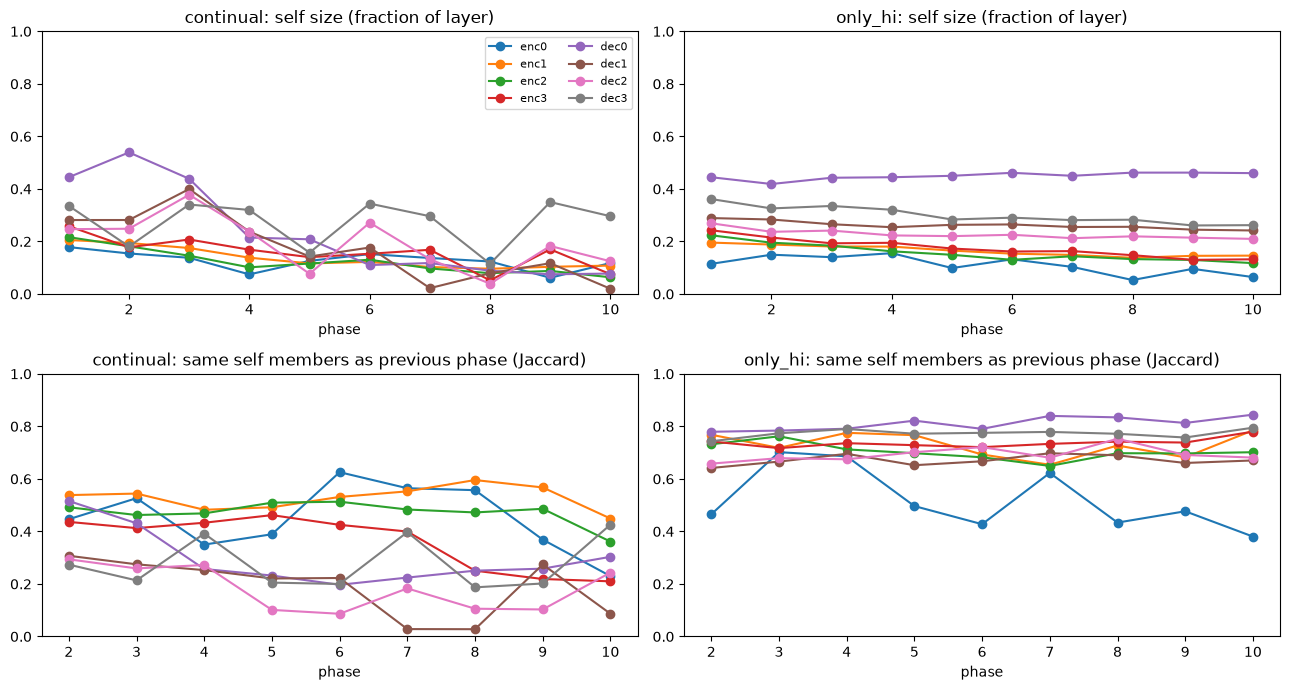

In [11]:
fig, axes = plt.subplots(2, len(results), figsize=(6.5 * len(results), 7), squeeze=False)
for col, (name, r) in enumerate(results.items()):
    B = r["blocks"][(r["blocks"].tau == TAU_PLOT) & (r["blocks"].phase >= 1)]
    T = r["trans"][r["trans"].tau == TAU_PLOT]
    for l in LAYERS:
        b, t = B[B.layer == l], T[T.layer == l]
        axes[0, col].plot(b.phase, b.self_frac, marker="o", label=l)
        axes[1, col].plot(t.to_phase, t.self_overlap, marker="o", label=l)
    axes[0, col].set_ylim(0, 1); axes[0, col].set_title(f"{name}: self size (fraction of layer)")
    axes[1, col].set_ylim(0, 1); axes[1, col].set_title(f"{name}: same self members as previous phase (Jaccard)")
    for ax in axes[:, col]:
        ax.set_xlabel("phase")
axes[0, 0].legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_self_size_overlap_tau{TAU_PLOT}.png", dpi=120); plt.show()

## 8. Change at each transition: self vs task vs random (lower = more stable)

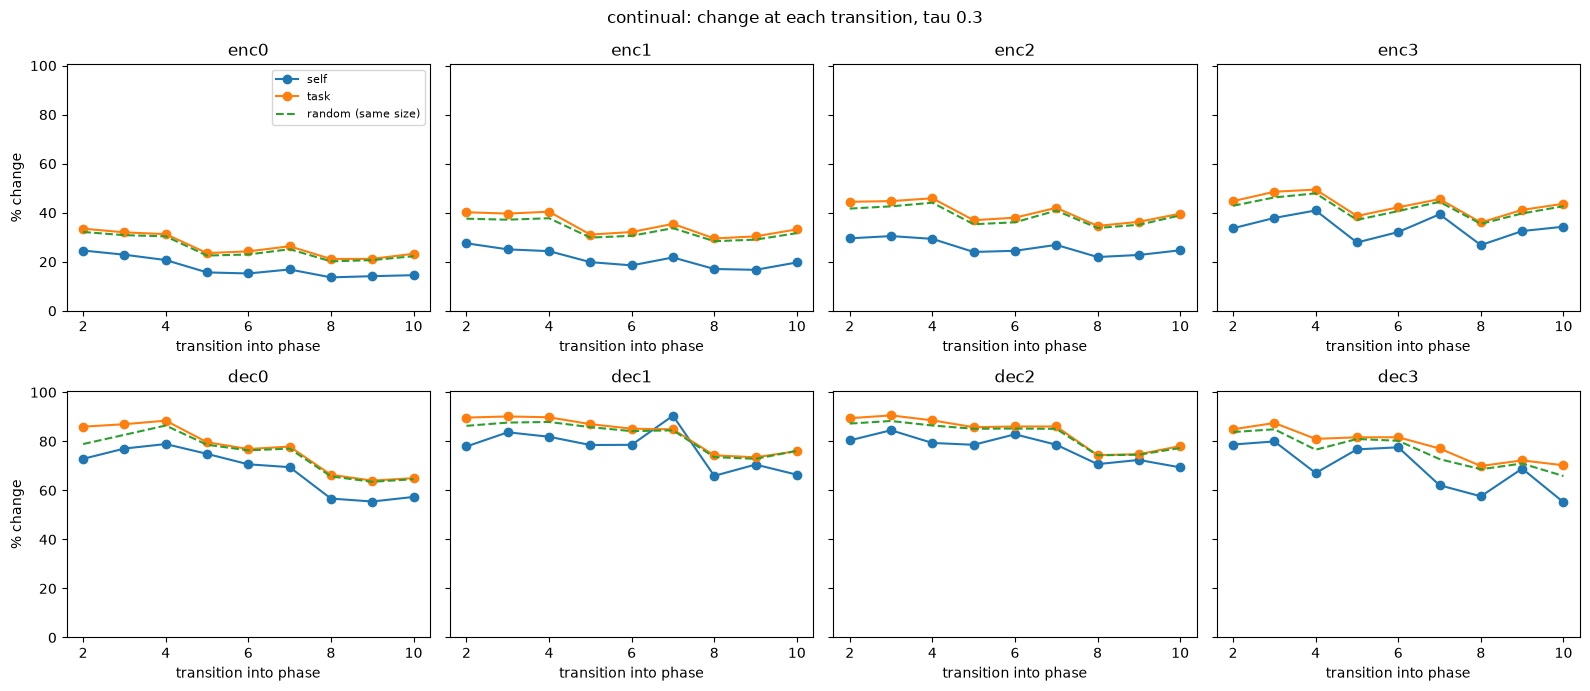

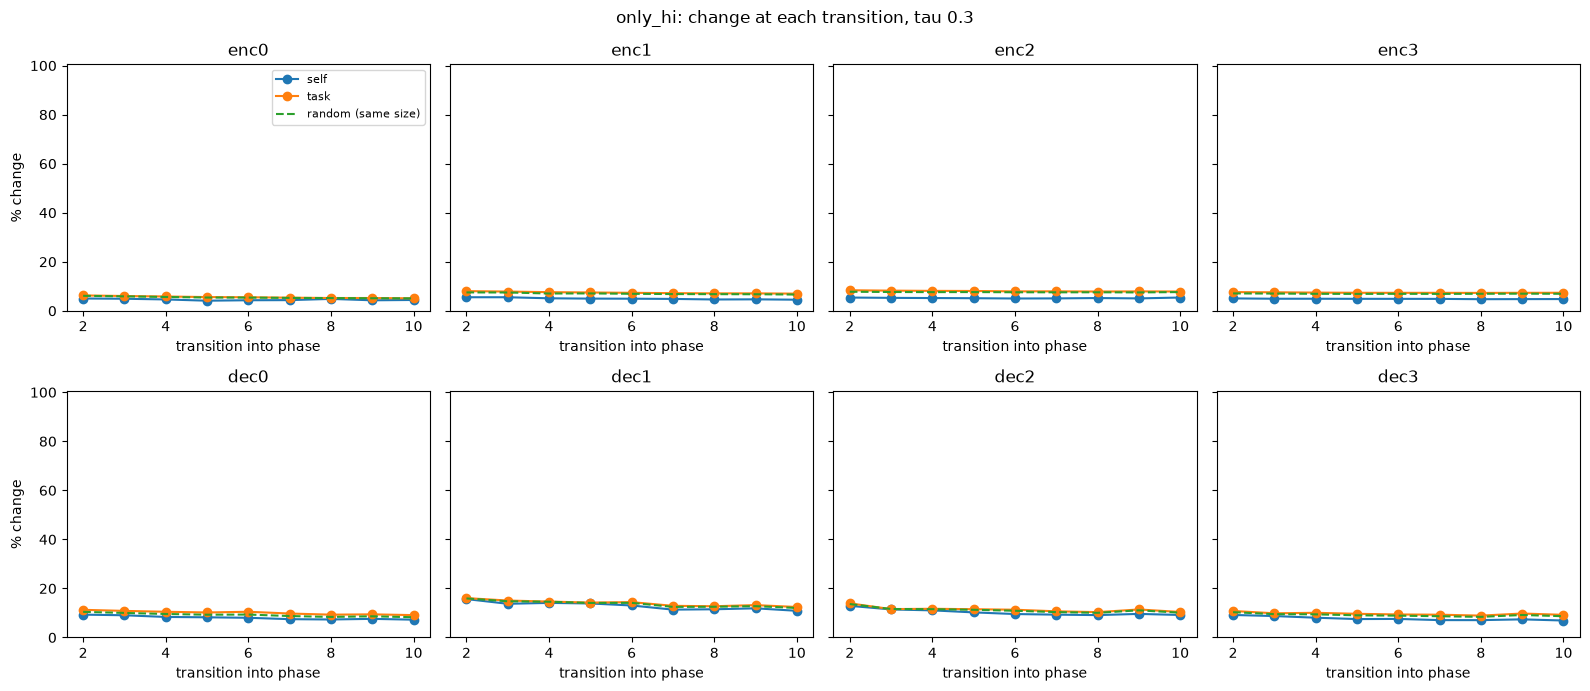

In [12]:
ymax = max(r["trans"].task_change.max() for r in results.values() if not r["trans"].empty)
for name, r in results.items():
    T = r["trans"][r["trans"].tau == TAU_PLOT]
    if T.empty:
        print(f"{name}: needs at least 2 trained checkpoints"); continue
    fig, axes = plt.subplots(2, len(LAYERS) // 2, figsize=(4 * len(LAYERS) // 2, 7), sharey=True, squeeze=False)
    for ax, l in zip(axes.flat, LAYERS):
        t = T[T.layer == l]
        ax.plot(t.to_phase, t.self_change, marker="o", label="self")
        ax.plot(t.to_phase, t.task_change, marker="o", label="task")
        ax.plot(t.to_phase, t.random_change, ls="--", label="random (same size)")
        ax.set_title(l); ax.set_xlabel("transition into phase"); ax.set_ylim(0, ymax * 1.05)
    axes[0, 0].set_ylabel("% change"); axes[1, 0].set_ylabel("% change"); axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"{name}: change at each transition, tau {TAU_PLOT}")
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_change_{name}_tau{TAU_PLOT}.png", dpi=120); plt.show()

## 9. Summary tables
`gap` = task change − self change (> 0: self more stable). `self_overlap` = how much the self keeps the same neurons from one phase to the next.

In [13]:
rows = []
for name, r in results.items():
    T = r["trans"]
    if T.empty:
        continue
    for tau in TAUS:
        for l in LAYERS:
            t = T[(T.tau == tau) & (T.layer == l)]
            b = r["blocks"][(r["blocks"].tau == tau) & (r["blocks"].layer == l) & (r["blocks"].phase >= 1)]
            rows.append({"run": name, "tau": tau, "layer": l, "self_frac": b.self_frac.mean(),
                         "self_change": t.self_change.mean(), "task_change": t.task_change.mean(),
                         "random_change": t.random_change.mean(), "gap": t.gap.mean(),
                         "% transitions self more stable": 100 * (t.gap > 0).mean(),
                         "self_overlap": t.self_overlap.mean(), "n_transitions": len(t)})
S = pd.DataFrame(rows)
S.to_csv(f"{OUT}/summary_all_taus.csv", index=False)
print(f"per layer, tau {TAU_PLOT}:")
display(S[S.tau == TAU_PLOT].drop(columns="tau").round(2))
print("averaged over layers, every tau:")
display(S.groupby(["tau", "run"])[["self_frac", "gap", "% transitions self more stable", "self_overlap"]].mean()
         .unstack("run").round(2))
print(f"saved to {OUT}")

per layer, tau 0.3:


,run,layer,self_frac,self_change,task_change,random_change,gap,% transitions self more stable,self_overlap,n_transitions
24,continual,enc0,0.13,17.59,26.28,25.24,8.69,100.00,0.45,9
25,continual,enc1,0.14,21.18,34.67,32.87,13.49,100.00,0.53,9
26,continual,enc2,0.12,26.02,40.29,38.72,14.27,100.00,0.47,9
27,continual,enc3,0.16,33.95,43.34,41.89,9.39,100.00,0.36,9
28,continual,dec0,0.23,68.13,76.78,74.85,8.64,100.00,0.30,9
29,continual,dec1,0.18,77.08,83.38,82.09,6.30,88.89,0.19,9
30,continual,dec2,0.19,77.42,83.73,82.61,6.31,100.00,0.18,9
31,continual,dec3,0.27,69.30,78.46,76.06,9.16,100.00,0.28,9
72,only_hi,enc0,0.11,4.56,5.58,5.46,1.03,100.00,0.52,9
73,only_hi,enc1,0.16,4.98,7.42,7.02,2.44,100.00,0.73,9


averaged over layers, every tau:


self_frac               gap         % transitions self more stable  \
run  continual only_hi continual only_hi                      continual   
tau                                                                       
0.15      0.90    0.91      8.25    2.54                         100.00   
0.20      0.62    0.63      7.36    1.89                         100.00   
0.25      0.36    0.39      7.98    1.84                         100.00   
0.30      0.18    0.23      9.53    1.88                          98.61   
0.40      0.04    0.09     15.96    2.50                          98.61   
0.50      0.02    0.04     20.15    3.28                          97.22   

             self_overlap          
run  only_hi    continual only_hi  
tau                                
0.15  100.00         0.86    0.93  
0.20  100.00         0.62    0.83  
0.25  100.00         0.48    0.78  
0.30  100.00         0.34    0.71  
0.40   98.61         0.33    0.68  
0.50  100.00         0.35    0.71

saved to /workspace/shreshth/analysis/v4
